# Minimal-Cost Password-Leak Attacks (API-first)

This notebook uses Python APIs (no CLI wrappers) to:
- generate and verify scenarios,
- compute **minimal-cost combinations** that break queries,
- render attack trees for `no pw leakage`.

In [4]:
import sys

from pathlib import Path
import pandas as pd
from IPython.display import Markdown, SVG, display

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

for module_name in list(sys.modules):
    if module_name == "proverifbatch" or module_name.startswith("proverifbatch."):
        del sys.modules[module_name]

from proverifbatch.scenarios import ScenarioPreprocessor
from proverifbatch.attack_tree import AttackTreeExtractor

EXAMPLES = [
    PROJECT_ROOT / "examples" / "hashed_passwords.pv",
    PROJECT_ROOT / "examples" / "singularized_passwords.pv",
]

TARGET_QUERY_TAG = "no pw leakage"

# Generate full scenario combinations so pinned multi-capability scenarios exist.
pre = ScenarioPreprocessor(timeout=300, check_all_scenarios=True)
atk = AttackTreeExtractor(timeout=300)

In [5]:
# Generate scenarios + run ProVerif via API
all_generated = []
file_to_generated = {}
file_to_generated_by_name = {}

for input_file in EXAMPLES:
    input_key = str(input_file)
    generated, out_dir = pre.preprocess(input_key)
    file_to_generated[input_key] = generated
    file_to_generated_by_name[input_key] = {
        scenario.path.name: scenario for scenario in generated
    }
    all_generated.extend(generated)

results = pre.run_proverif(all_generated)
analysis = pre.analyze(results, [str(p) for p in EXAMPLES])

# Build compact table focused on the no pw leakage query
rows = []
for input_file, by_query in analysis.items():
    model = Path(input_file).stem
    combos = by_query.get(TARGET_QUERY_TAG, [])
    for combo in combos:
        caps = sorted(combo["scenarios"])

        cost_items = sorted(combo["costs"].items())
        rows.append({
            "model": model,
            "query": TARGET_QUERY_TAG,
            "minimal_combo": " + ".join(caps) if caps else "base",
            "costs": ", ".join(f"{k}:{v}" for k, v in cost_items) if cost_items else "none",
        })

df_min = pd.DataFrame(rows)
display(df_min.sort_values(["model", "minimal_combo"]).reset_index(drop=True))


Processing: /home/ben/Documents/orange/orangeproject/examples/hashed_passwords.pv
Attacker capabilities with costs
------------------------------------------------------------
Capability                                    hack         time
---------------------------------------------------------------
Rainbow table attack                             -           10
Intruder at database                             1            -

Total scenarios generated: 4

Processing: /home/ben/Documents/orange/orangeproject/examples/singularized_passwords.pv
Attacker capabilities with costs
------------------------------------------------------------
Capability                                    hack         time
---------------------------------------------------------------
Rainbow table attack                             -          100
Live intrusion at singularization se             1            -
Intruder at database                             1            -
Intruder at singularization databa

,model,query,minimal_combo,costs
0,hashed_passwords,no pw leakage,Intruder at database + Rainbow table attack,"hack:1, time:10"
1,singularized_passwords,no pw leakage,Intruder at database + Intruder at singulariza...,"hack:2, time:100"


### hashed_passwords — rainbow_table_attack+intruder_at_database.pv

- Minimal combo: `Intruder at database, Rainbow table attack`  
- Costs: `{'time': 10, 'hack': 1}`

- Scenario capabilities: `Intruder at database, Rainbow table attack`

Capability nodes shown: 2


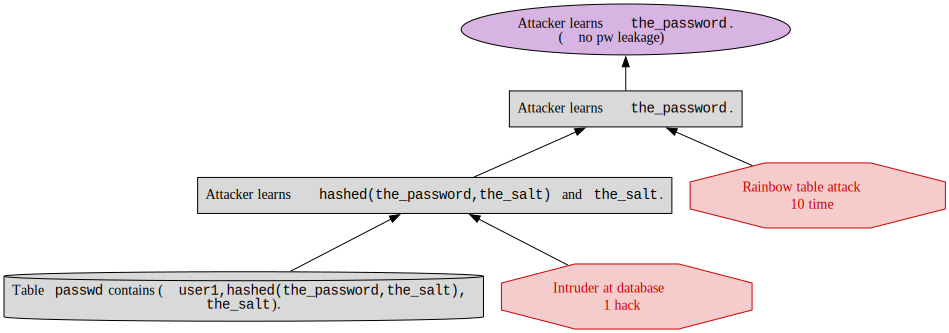

### singularized_passwords — rainbow_table_attack+intruder_at_database+intruder_at_singularization_database.pv

- Minimal combo: `Intruder at database, Intruder at singularization database, Rainbow table attack`  
- Costs: `{'time': 100, 'hack': 2}`

- Scenario capabilities: `Intruder at database, Intruder at singularization database, Rainbow table attack`

No capability-specific clauses could be attributed inside this derivation tree; the active scenario capabilities are listed above.


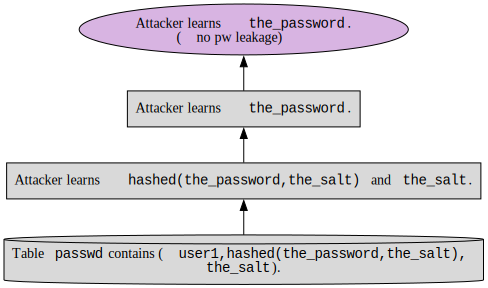

In [ ]:
## Attack Trees for `no pw leakage` (rendered inline)

# Render the pinned scenarios for the no pw leakage query.

PINNED_SCENARIOS = {
    str(EXAMPLES[0]): "rainbow_table_attack+intruder_at_database.pv",
    str(EXAMPLES[1]): "rainbow_table_attack+intruder_at_database+intruder_at_singularization_database.pv",
}

for input_file in map(str, EXAMPLES):
    scenario = file_to_generated_by_name[input_file][PINNED_SCENARIOS[input_file]]
    build = atk.extract_tree(
        scenario.path,
        query_tag=TARGET_QUERY_TAG,
        scenario_queries=scenario.queries,
        capability_scenarios=file_to_generated[input_file],
        readable_nodes=True,
        show_clause_ids=False,
    )

    combo_scenarios = sorted(capability.name for capability in scenario.capabilities)
    model = Path(input_file).stem

    display(Markdown(f"### {model} — {scenario.path.name}"))
    display(Markdown(f"- Minimal combo: `{', '.join(combo_scenarios) or 'base'}`  \n- Costs: `{scenario.costs}`"))
    display(Markdown(f"- Scenario capabilities: `{', '.join(combo_scenarios) or 'base'}`"))


    capability_node_count = sum(
        1 for node in build.tree.nodes.values() if node.node_type == "capability"
    )
    if capability_node_count == 0:
        print("No capability-specific clauses could be attributed inside this derivation tree; the active scenario capabilities are listed above.")
    else:
        print(f"Capability nodes shown: {capability_node_count}")

    dot = build.tree.to_graphviz()
    try:
        import graphviz
        src = graphviz.Source(dot, format="svg")
        svg = src.pipe(format="svg").decode("utf-8")
        display(SVG(svg))
    except Exception:
        # Inline SVG rendering unavailable. Showing DOT snippet:"
        print("\n".join(dot.splitlines()[:20]))